# Ximenez Line Map (XML TO CSV)

Map Ximenez line breaks with paragraphs.

In [1]:
import pandas as pd
import re
pd.set_option('display.max_colwidth', False)

# Load

In [2]:
xml_lines = open("xom-all-flat-mod-pnums.xml").readlines()

# Parse

In [3]:
els = dict(
    lang = '',
    folio = 0,
    side = 0,
    para = 0,
    lb = 0,
    lb_n  = '' # Line number as given
)

data = []
ana_list = []

for line in xml_lines:
    
    # Grab column (lang) 
    # Pattern: <div xml:lang="quc" type="column" rend="left half">
    if re.match(r"<div xml:lang", line):
        els['lang'] = line.split('"')[1].split('"')[0]
        els['para'] = 0

    # Grab manuscript
    if re.match(r"^<pb ", line):
        f, s = line.split("xom-")[1].split('"')[0].split('-')
        els['folio'] = int(f[1:])
        els['side'] = int(s[1:])
        els['lb'] = 0

    # Grab paragraph
    if re.match(r"^<p ", line):
        els['para'] += 1

    # Grab line break
    if re.match(r"^<lb n=", line):
        els['lb_n'] = line.split('<lb n="')[1].split('"')[0]
        els['lb'] += 1
        els['lb_str'] = ' '.join(line.split("/>")[1:]).strip()
        
        # Grab RS elements
        ana_num = 0
        rs = line.split("<rs ")
        if len(rs) > 1:
            for r in rs[1:]:
                ana = r.split('"')[1]  
                ana_num += 1
                ana_list.append((els['lang'], els['folio'], els['side'], els['para'], els['lb'], els['lb_n'], ana_num, ana))
            
        data.append(tuple(els.values()))

In [4]:
ana_cols = list(els.keys())[:-1] + ['ana_num', 'ana_id']

In [5]:
TEMA_SEQ = pd.DataFrame(ana_list, columns = ana_cols).set_index(ana_cols[:-1])

In [6]:
LINE = pd.DataFrame(data, columns=els.keys())
LINE = LINE.set_index(['lang', 'folio', 'side', 'para', 'lb'])

In [7]:
assert LINE.index.has_duplicates == False, "LINE has duplicates"

# Clean

In [8]:
LINE['lb_str_plain'] = LINE.lb_str.str.replace(r"<[^>]+/?>", "", regex=True).str.replace(" –", "–", regex=False)

In [9]:
chars = {
    'Ꜩ': 'Tz',
    'ꜩ': 'tz',
    'ꜫ': "q'",
    'ÿ': 'i', # 'ij' 
}

In [10]:
for char in chars:
    LINE.lb_str_plain = LINE.lb_str_plain.str.replace(char, chars[char], regex=False)

# TEMAs

In [37]:
TEMA = TEMA_SEQ.reset_index().value_counts(['lang','ana_id']).sort_index().to_frame('n')

In [89]:
TEMAX = TEMA.unstack(fill_value=0) #.T.sort_values('quc', ascending=False)
TEMAX.columns = TEMAX.columns.droplevel(0)
TEMAX = TEMAX.T 

In [90]:
# TEMAX.index

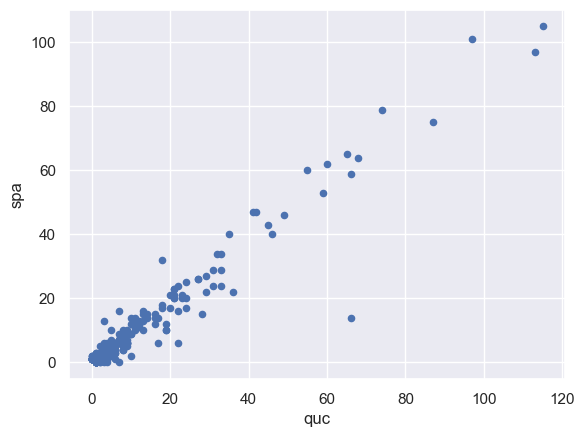

In [91]:
TEMAX.plot.scatter('quc', 'spa');

In [92]:
TEMAX['diff'] = (TEMAX.quc - TEMAX.spa) 

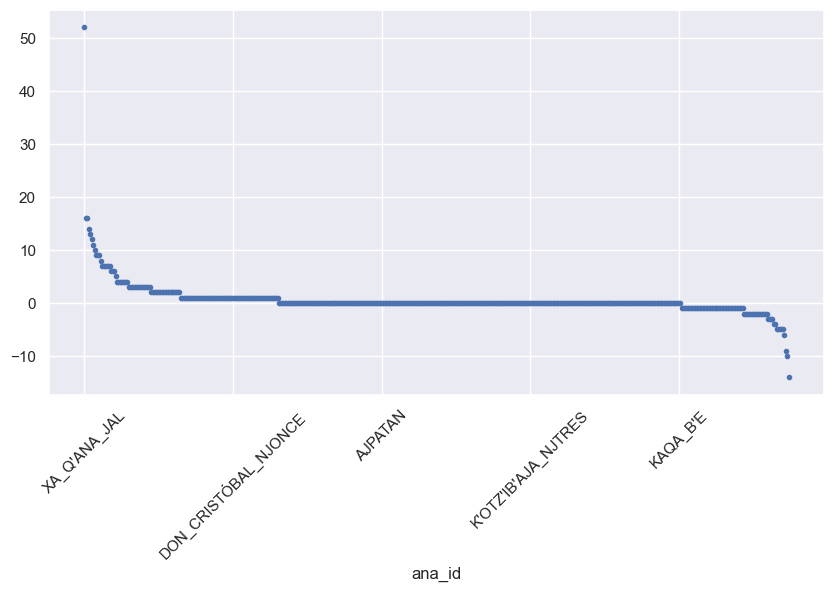

In [94]:
TEMAX.sort_values('diff', ascending=False)['diff'].plot(figsize=(10, 5), rot=45, style='.');

# Visualize

In [95]:
import seaborn as sns # Plotting
import matplotlib.pyplot as plt # Plotting
sns.set_theme(style="darkgrid") # Set seaborn theme


In [96]:
TEMA_SEQ_QUC = TEMA_SEQ.loc['quc'].reset_index()

In [97]:
# fig, ax = plt.subplots(figsize=(10, 75))
# sns.stripplot(x=TEMA_SEQ.reset_index().index, y=TEMA_SEQ.ana_id, ax=ax);

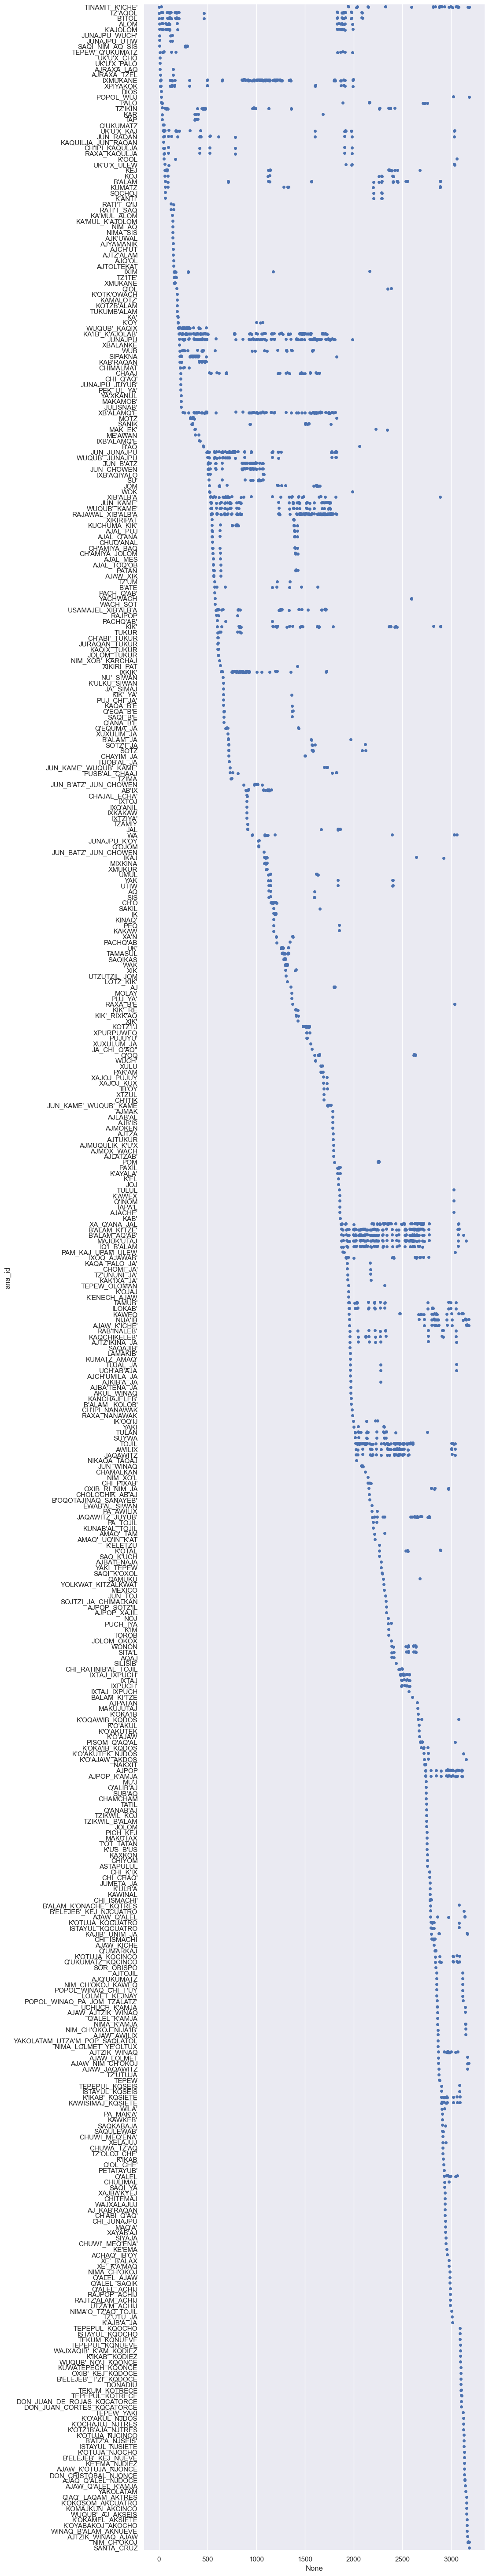

In [98]:
fig, ax = plt.subplots(figsize=(10, 75))
sns.stripplot(x=TEMA_SEQ_QUC.reset_index().index, y=TEMA_SEQ_QUC.ana_id, ax=ax);

# Save

In [99]:
for lang in ['spa', 'quc']:
    LINE.loc[lang].to_csv(f"ximenez-{lang}-LINE.csv", index=True, sep='|')
    TEMA_SEQ.loc[lang].to_csv(f"ximenez-{lang}-TEMA_SEQ.csv", index=True, sep='|')
    
TEMAX.to_csv(f"ximenez-{lang}-TEMAX.csv", index=True, sep='|')

In [102]:
TEMAX.sort_values('diff', ascending=False)

lang,quc,spa,diff
ana_id,,,
XA_Q'ANA_JAL,66,14,52
RAJAWAL_XIB'ALB'A,113,97,16
AJPOP,22,6,16
XIB'ALB'A,36,22,14
WUB,28,15,13
...,...,...,...
CHI_ISMACHI',5,10,-5
IQ'I_B'ALAM,41,47,-6
SUYWA,7,16,-9
